# Dissertation: Autonomous Agent for Alpha Discovery in Indian Equity Markets

**Author:** Abhinav Gazta  
**Course:** S1-25_AIMLCZG628T (Dissertation)  
**Topic:** Financial Machine Learning & Deep Reinforcement Learning (DRL)

---

## 1. Abstract & Objectives

This notebook implements a state-of-the-art **Deep Reinforcement Learning (DRL)** framework to optimize portfolio allocation on the NSE/BSE. Unlike traditional backtests, this solution addresses **Non-Stationarity** and **Look-Ahead Bias** using **Walk-Forward Validation** and **Bayesian Hyperparameter Tuning**.

### Key Technical Components:
1.  **Hybrid Transformer-PPO Architecture:** Uses Self-Attention to capture long-term market regimes.
2.  **Dynamic Cost Simulator:** Models Linear (STT/Brokerage) and Quadratic (Impact Cost) frictions.
3.  **Bayesian Optimization (Optuna):** Automatically tunes Learning Rate, Entropy, and Reward Penalties.
4.  **Walk-Forward Validation:** A rolling-window evaluation to ensure the agent adapts to changing markets.
5.  **Explainable AI (XAI):** Uses SHAP values to interpret the "Black Box" decision-making process.
6.  **Statistical Rigor:** Monte Carlo Permutation tests to validate if Alpha is statistically significant ($p < 0.05$).

In [17]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
import scipy.stats as stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu



--- Generating Market Regime Analysis for RELIANCE.NS ---


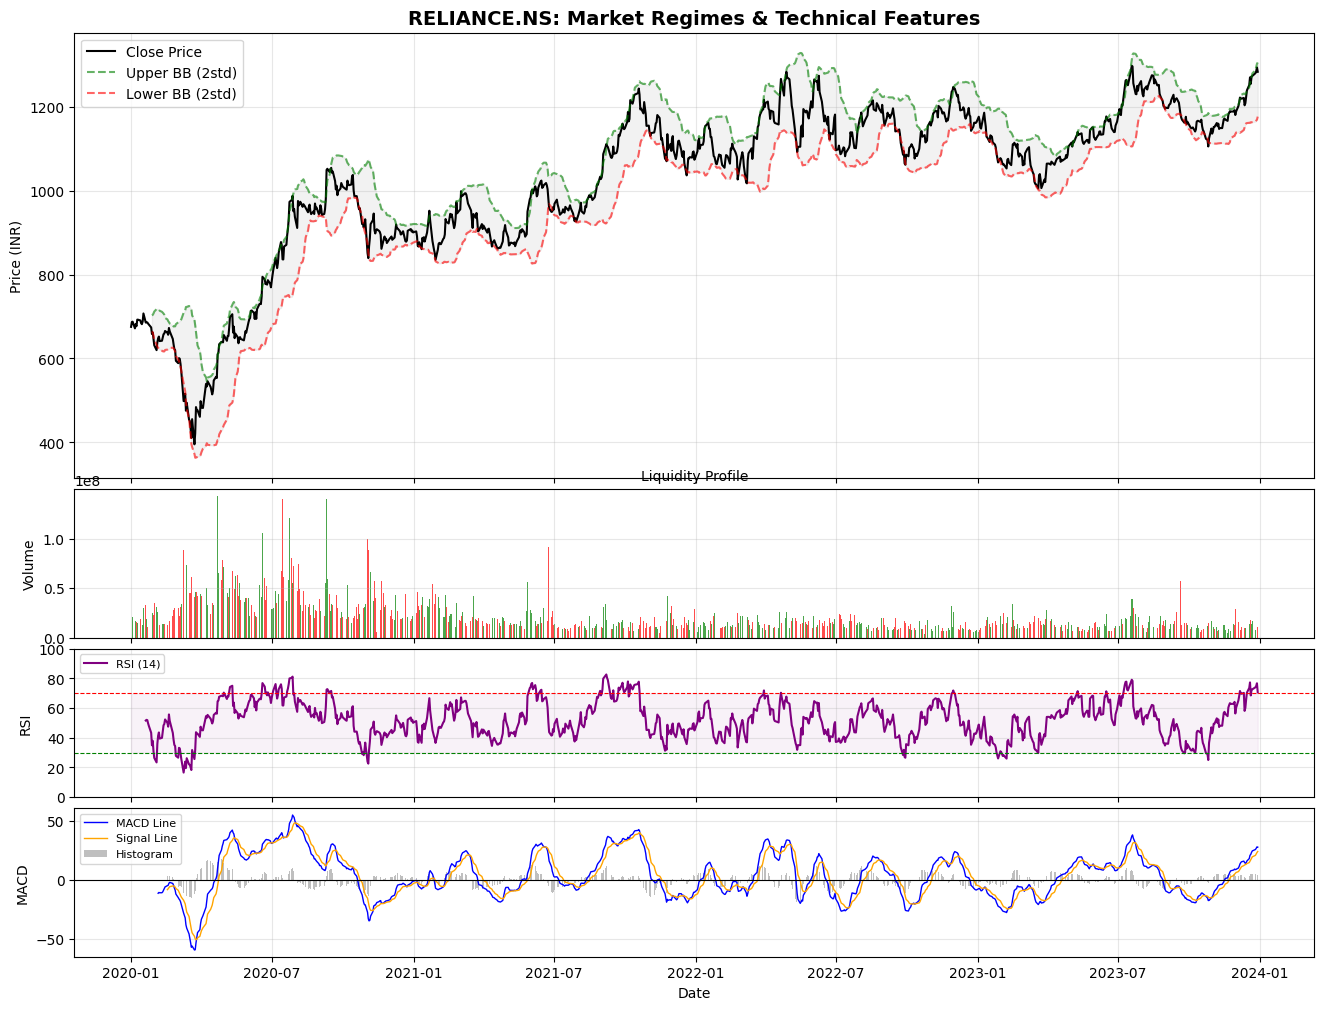


--- Generating Market Regime Analysis for INFY.NS ---


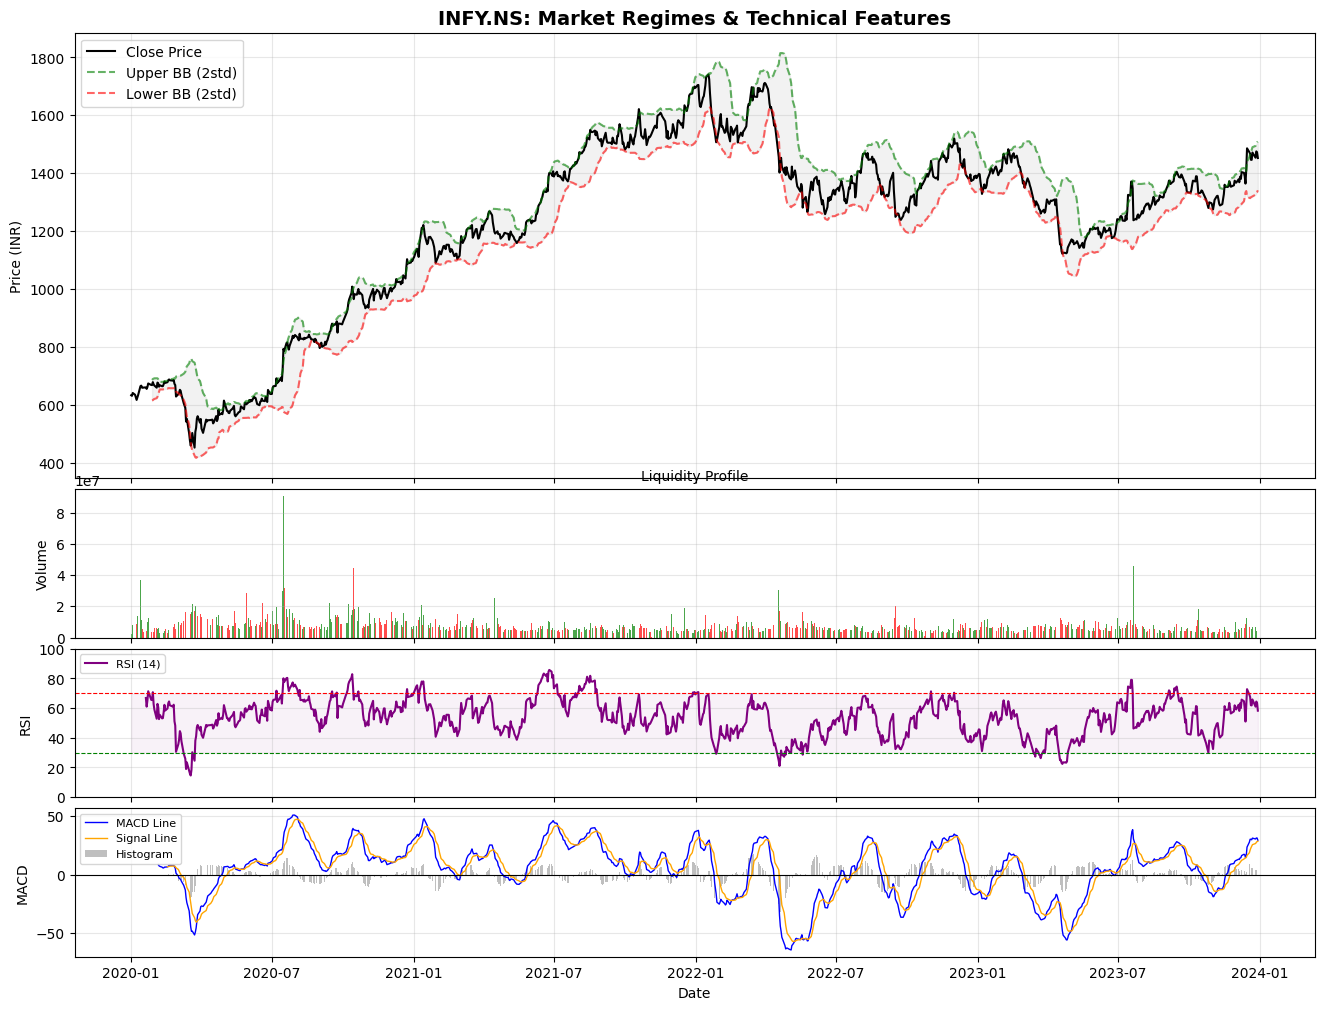


--- Generating Market Regime Analysis for HDFCBANK.NS ---


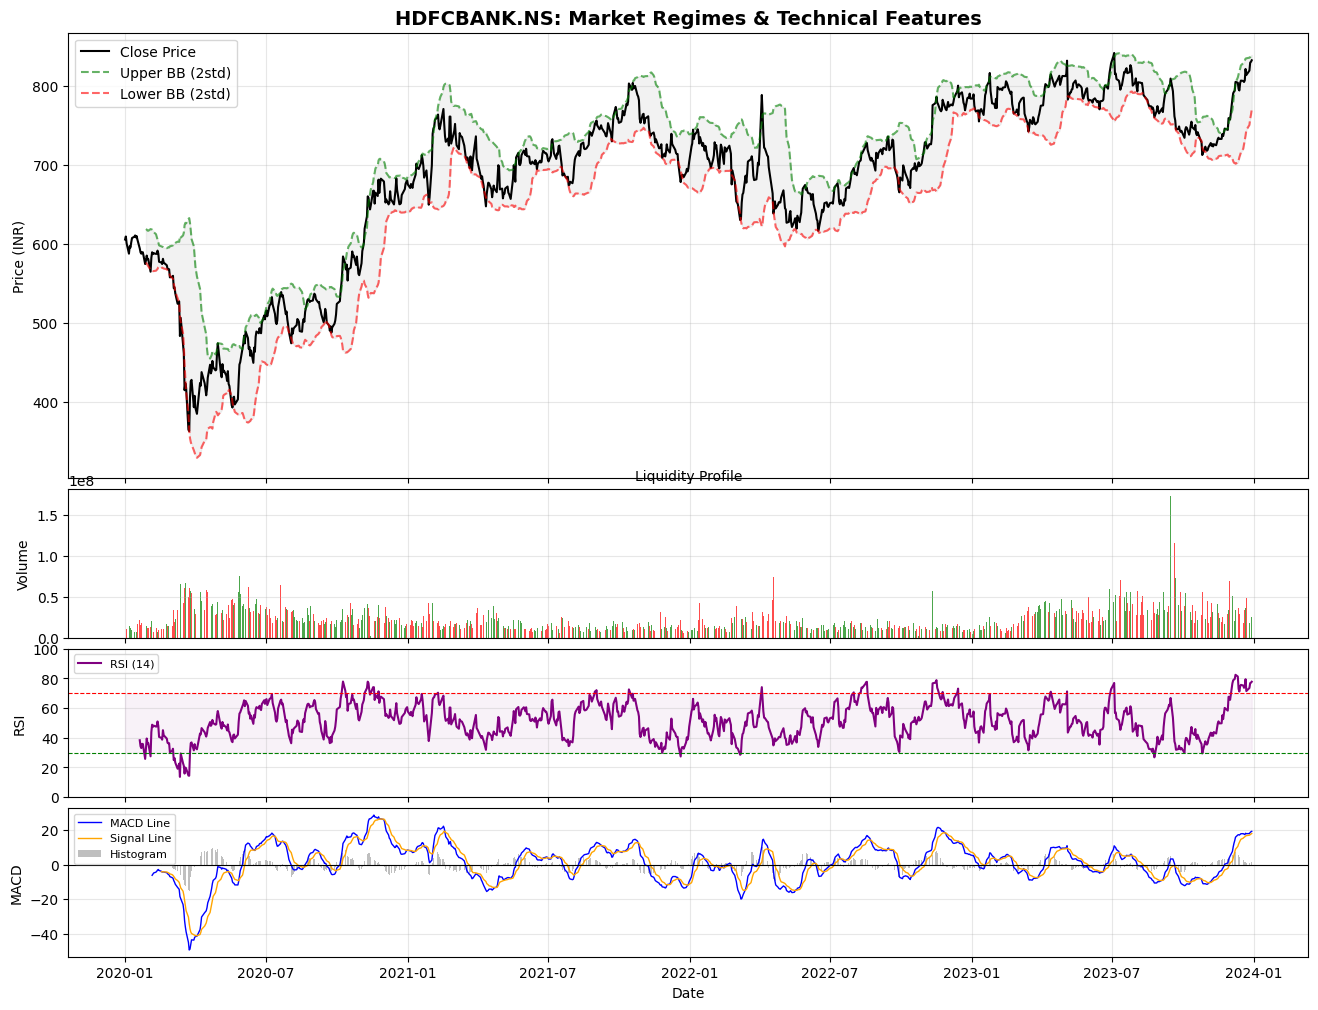


--- Generating Market Regime Analysis for TCS.NS ---


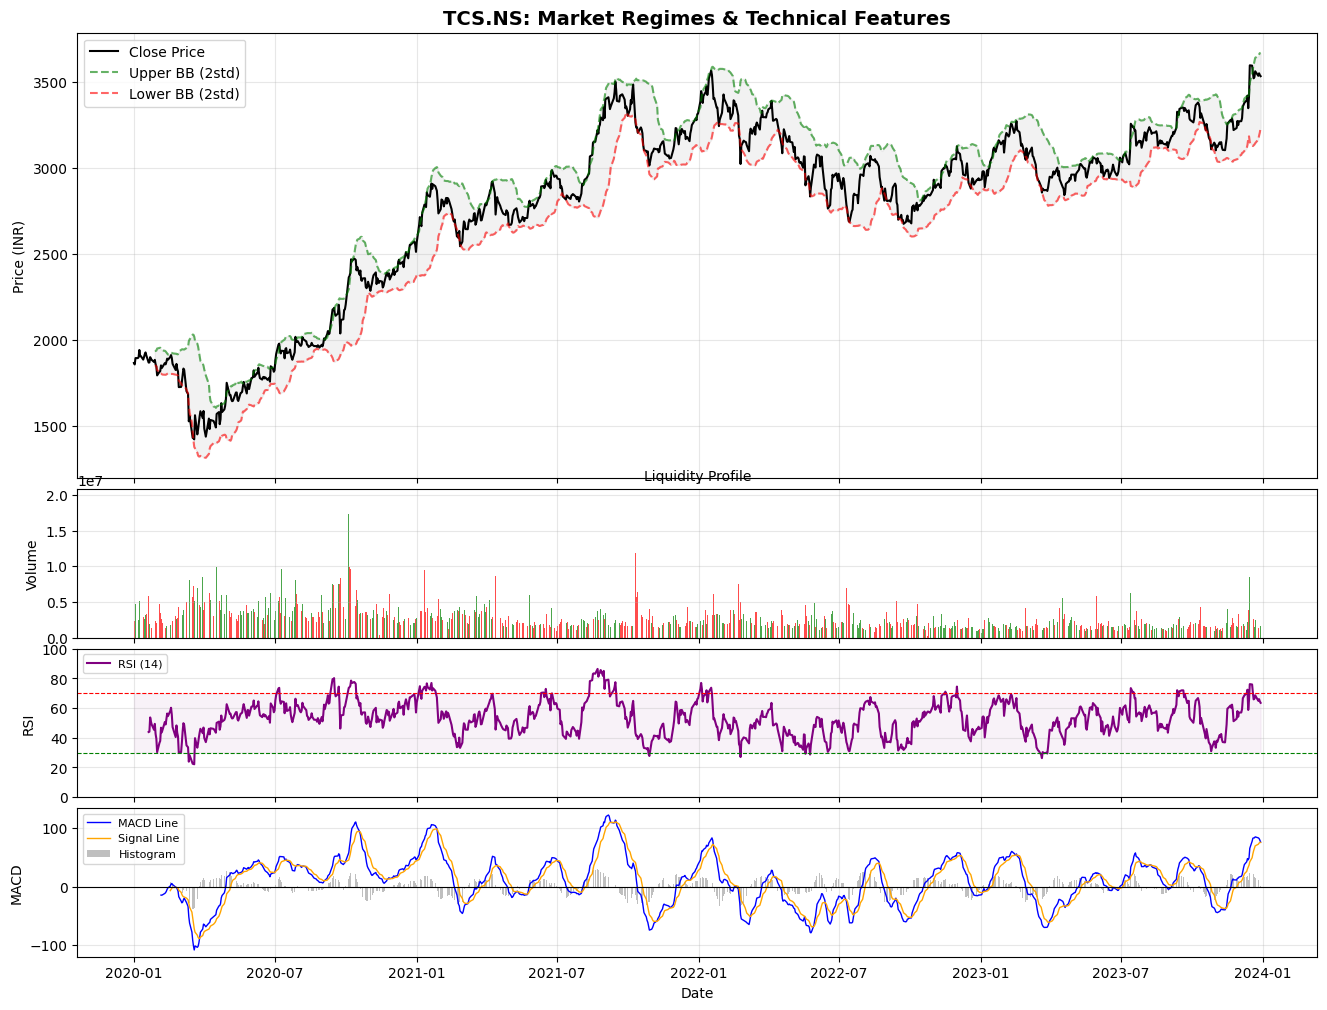

In [18]:
# ==========================================
# 1.1 VISUALIZATION MODULE (EDA) - FIXED
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def visualize_market_dynamics(ticker, start_date="2020-01-01", end_date="2024-01-01"):
    """
    Generates a professional financial dashboard for Dissertation EDA.
    Visualizes Price, Volatility (BB), Momentum (RSI), and Trend (MACD).
    """
    print(f"\n--- Generating Market Regime Analysis for {ticker} ---")
    
    # 1. Fetch RAW Data
    # auto_adjust=True handles splits/dividends
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    
    if df.empty:
        print("Error: No data found for ticker.")
        return

    # --- FIX: Flatten MultiIndex columns if present ---
    # This prevents the (N, 1) dimension error
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    # --- FIX: Ensure 'Close' is a 1D Series ---
    # use .squeeze() to convert single-column DataFrame to Series
    close_series = df['Close'].squeeze()

    # 2. Compute Indicators (Matching Agent's Logic)
    # Bollinger Bands (Volatility)
    # Pass the 1D series explicitly
    bb = ta.volatility.BollingerBands(close_series)
    df['bb_high'] = bb.bollinger_hband()
    df['bb_low'] = bb.bollinger_lband()
    
    # RSI (Momentum)
    df['rsi'] = ta.momentum.RSIIndicator(close_series, window=14).rsi()
    
    # MACD (Trend)
    macd_ind = ta.trend.MACD(close_series)
    df['macd'] = macd_ind.macd()
    df['macd_signal'] = macd_ind.macd_signal()
    df['macd_hist'] = macd_ind.macd_diff()
    
    # 3. Create Dashboard (4 Subplots)
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True, 
                             gridspec_kw={'height_ratios': [3, 1, 1, 1], 'hspace': 0.05})
    
    # Plot A: Price & Volatility Regimes
    axes[0].plot(df.index, df['Close'], label='Close Price', color='black', linewidth=1.5)
    axes[0].plot(df.index, df['bb_high'], label='Upper BB (2std)', color='green', linestyle='--', alpha=0.6)
    axes[0].plot(df.index, df['bb_low'], label='Lower BB (2std)', color='red', linestyle='--', alpha=0.6)
    axes[0].fill_between(df.index, df['bb_high'], df['bb_low'], color='gray', alpha=0.1)
    axes[0].set_title(f"{ticker}: Market Regimes & Technical Features", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Price (INR)")
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # Plot B: Volume (Liquidity)
    # Handle Volume being Series or DataFrame
    vol = df['Volume'].squeeze()
    colors = ['green' if o < c else 'red' for o, c in zip(df['Open'], df['Close'])]
    axes[1].bar(df.index, vol, color=colors, alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_title("Liquidity Profile", fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Plot C: RSI (Momentum)
    axes[2].plot(df.index, df['rsi'], color='purple', label='RSI (14)')
    axes[2].axhline(70, color='red', linestyle='--', linewidth=0.8)
    axes[2].axhline(30, color='green', linestyle='--', linewidth=0.8)
    axes[2].fill_between(df.index, 70, 30, color='purple', alpha=0.05)
    axes[2].set_ylabel("RSI")
    axes[2].set_ylim(0, 100)
    axes[2].legend(loc='upper left', fontsize=8)
    axes[2].grid(True, alpha=0.3)
    
    # Plot D: MACD (Trend)
    axes[3].plot(df.index, df['macd'], label='MACD Line', color='blue', linewidth=1)
    axes[3].plot(df.index, df['macd_signal'], label='Signal Line', color='orange', linewidth=1)
    axes[3].bar(df.index, df['macd_hist'], label='Histogram', color='gray', alpha=0.5)
    axes[3].set_ylabel("MACD")
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].legend(loc='upper left', fontsize=8)
    axes[3].grid(True, alpha=0.3)
    
    # Formatting
    axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

# Run the fixed function
visualize_market_dynamics('RELIANCE.NS', start_date="2020-01-01", end_date="2024-01-01")
visualize_market_dynamics('INFY.NS', start_date="2020-01-01", end_date="2024-01-01")
visualize_market_dynamics('HDFCBANK.NS', start_date="2020-01-01", end_date="2024-01-01")
visualize_market_dynamics('TCS.NS', start_date="2020-01-01", end_date="2024-01-01")

## 2. Advanced Financial Metrics Library

To validate the agent's performance, we implement a robust metrics library. This includes the **Probabilistic Sharpe Ratio (PSR)**, which adjusts the standard Sharpe Ratio for skewness and kurtosis, providing a confidence level that the strategy is truly profitable.

In [19]:
class FinancialMetrics:
    @staticmethod
    def get_max_drawdown(prices):
        prices = np.array(prices)
        if len(prices) < 2: return 0.0
        peaks = np.maximum.accumulate(prices)
        # Avoid division by zero
        with np.errstate(divide='ignore', invalid='ignore'):
            drawdowns = (prices - peaks) / (peaks + 1e-9)
        return np.min(np.nan_to_num(drawdowns))

    @staticmethod
    def get_sharpe_ratio(returns, risk_free_rate=0.06):
        returns = np.nan_to_num(returns)
        if len(returns) < 2: return 0.0
        
        # Annualized Excess Return
        excess_ret = returns - (risk_free_rate / 252)
        std_dev = np.std(excess_ret)
        
        if std_dev < 1e-9: return 0.0
        
        # Annualize Sharpe
        return (np.mean(excess_ret) / std_dev) * np.sqrt(252)

    @staticmethod
    def get_sortino_ratio(returns, risk_free_rate=0.06):
        returns = np.nan_to_num(returns)
        excess_ret = returns - (risk_free_rate / 252)
        downside_returns = excess_ret[excess_ret < 0]
        
        downside_std = np.std(downside_returns)
        if downside_std < 1e-9: return 0.0
        
        return (np.mean(excess_ret) / downside_std) * np.sqrt(252)

    @staticmethod
    def probabilistic_sharpe_ratio(returns, benchmark_sharpe=0):
        """
        Calculates the probability that the strategy's Sharpe Ratio is greater than the benchmark.
        Adjusts for non-normal distribution (Skew/Kurtosis).
        """
        returns = np.nan_to_num(returns)
        sr = FinancialMetrics.get_sharpe_ratio(returns)
        skew = stats.skew(returns)
        kurtosis = stats.kurtosis(returns)
        n = len(returns)
        
        if n < 2: return 0.0
        
        sr_std = np.sqrt((1 + (0.5 * skew * sr) + ((kurtosis - 3) / 4) * sr**2) / (n - 1))
        if sr_std < 1e-9: return 0.0
        
        z_stat = (sr - benchmark_sharpe) / sr_std
        return stats.norm.cdf(z_stat)

## 3. Data Engineering Layer

This layer handles the extraction and preprocessing of OHLCV data. 
**Crucial Step:** We engineer features that capture **Momentum** (RSI), **Trend** (MACD), **Volatility** (Bollinger Width), and **Liquidity** (Volume Ratio). All features are normalized using a rolling Z-score to ensure stationarity, which is critical for Neural Network stability.

In [20]:
def fetch_and_process_data(tickers, start_date="2015-01-01", end_date="2025-01-01"):
    print(f"Fetching data for {len(tickers)} assets...")
    data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')
    processed_frames = []
    
    for ticker in tickers:
        if len(tickers) == 1:
            df = data.copy()
        else:
            try:
                df = data[ticker].copy()
            except KeyError:
                continue
                
        if df.empty: continue
        
        # --- Feature Engineering ---
        # 1. Log Returns: Stationarity
        df['log_ret'] = np.log(df['Close'] / (df['Close'].shift(1) + 1e-8))
        
        # 2. Momentum & Trend
        df['rsi'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi() / 100.0
        macd = ta.trend.MACD(df['Close'])
        df['macd'] = macd.macd_diff()
        
        # 3. Volatility
        bb = ta.volatility.BollingerBands(df['Close'])
        df['bb_width'] = (bb.bollinger_hband() - bb.bollinger_lband()) / (df['Close'] + 1e-8)
        df['atr'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
        
        # 4. Liquidity / Cost Proxies
        df['adv_20'] = df['Close'] * df['Volume'].rolling(window=20).mean()
        df['vol_ratio'] = (df['Close'] * df['Volume']) / (df['adv_20'] + 1e-8)
        
        df.dropna(inplace=True)
        
        # 5. Normalization (Rolling Z-Score)
        cols_to_norm = ['log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio']
        for col in cols_to_norm:
            rolling_mean = df[col].rolling(60).mean()
            rolling_std = df[col].rolling(60).std()
            df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-8)
            
        df['ticker'] = ticker
        processed_frames.append(df.dropna())

    if not processed_frames:
        raise ValueError("No data downloaded.")
        
    combined = pd.concat(processed_frames)
    pivot_df = combined.pivot_table(index='Date', columns='ticker', values=['Close', 'log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio', 'atr', 'adv_20'])
    
    # Clean Infinite/NaN values
    pivot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    pivot_df.dropna(inplace=True)
    
    return pivot_df

## 4. Market Simulator (Environment)

The `IndianEquityEnv` is a custom Gym environment designed to realistically simulate Indian market conditions. 

**Key Features:**
* **Action Space:** Continuous allocation vector (Softmax normalized).
* **Linear Costs:** Simulates STT (Securities Transaction Tax) and Brokerage.
* **Quadratic Costs:** Simulates **Slippage** (Market Impact) based on the trade size relative to the stock's Average Daily Volume (ADV). This penalizes the agent for trading too aggressively in illiquid stocks.
* **Dynamic Rewards:** The reward function's penalties (alpha, beta, gamma) are tunable hyperparameters.

In [21]:
class IndianEquityEnv(gym.Env):
    def __init__(self, df, reward_params=None, lookback_window=30, initial_balance=1_000_000):
        super(IndianEquityEnv, self).__init__()
        self.df = df
        self.tickers = df['Close'].columns.tolist()
        self.n_assets = len(self.tickers)
        self.lookback = lookback_window
        self.initial_balance = initial_balance
        
        # Tunable Reward Penalties
        self.reward_params = reward_params if reward_params else {
            'alpha': 0.001,  # Turnover penalty
            'beta': 0.1,     # Slippage penalty
            'gamma': 10.0    # Downside risk penalty
        }
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.n_features = 5 
        self.obs_shape = (lookback_window, self.n_assets * self.n_features)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=self.obs_shape, dtype=np.float32)
        self.stt_brokerage = 0.0015
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.lookback
        self.balance = self.initial_balance
        self.weights = np.zeros(self.n_assets + 1)
        self.weights[0] = 1.0 
        self.portfolio_value = self.initial_balance
        return self._get_obs(), {}

    def _get_obs(self):
        idx = self.current_step
        obs_data = []
        for feat in ['log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio']:
            obs_data.append(self.df[feat].iloc[idx-self.lookback:idx].values)
        return np.concatenate(obs_data, axis=1).astype(np.float32)

    def step(self, action):
        # Softmax normalization to get weights
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        
        current_prices = self.df['Close'].iloc[self.current_step].values
        next_prices = self.df['Close'].iloc[self.current_step + 1].values
        asset_returns = (next_prices - current_prices) / current_prices
        
        weighted_returns = np.dot(weights[1:], asset_returns)
        
        # Cost Calculation
        delta_weights = np.abs(weights - self.weights)
        turnover = np.sum(delta_weights)
        cost_linear = turnover * self.stt_brokerage
        
        advs = self.df['adv_20'].iloc[self.current_step].values
        trade_vals = delta_weights[1:] * self.portfolio_value
        slippage_penalty = self.reward_params['beta'] * np.sum((trade_vals / (advs + 1e-5))**2)
        
        net_ret = weighted_returns - cost_linear - (slippage_penalty / self.portfolio_value)
        
        # Downside Risk Penalty
        downside_penalty = min(0, net_ret)**2 * self.reward_params['gamma']
        explicit_turnover_penalty = turnover * self.reward_params['alpha']
        
        reward = net_ret - downside_penalty - explicit_turnover_penalty
        
        self.portfolio_value *= (1 + net_ret)
        self.weights = weights
        self.current_step += 1
        
        terminated = self.current_step >= len(self.df) - 1
        current_atr = self.df['atr'].iloc[self.current_step].mean() 
        
        info = {
            'portfolio_value': self.portfolio_value,
            'turnover': turnover,
            'atr': current_atr,
            'net_return': net_ret
        }
        
        return self._get_obs(), reward, terminated, False, info

## 5. Explainable Transformer Model

We use a custom **Transformer Encoder** as the feature extractor for the PPO agent. 

**Why Transformer?** Unlike LSTMs, Transformers process the entire sequence at once using Self-Attention mechanisms. This allows the model to identify specific past events (e.g., a crash 20 days ago) that are relevant to the current decision.

**Explainability Hook:** We capture the `attn_weights` in the `forward` pass. This allows us to visualize exactly which time-steps the agent is "looking at."

In [22]:
class ExplainableTransformer(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        
        self.seq_len = observation_space.shape[0]
        self.input_dim = observation_space.shape[1]
        self.d_model = 128
        
        self.linear_in = nn.Linear(self.input_dim, self.d_model)
        # Note: average_attn_weights=False is key for explainability
        self.mha = nn.MultiheadAttention(embed_dim=self.d_model, num_heads=4, batch_first=True)
        self.norm1 = nn.LayerNorm(self.d_model)
        self.linear_out = nn.Linear(self.seq_len * self.d_model, features_dim)
        self.act = nn.Tanh()
        
        self.latest_attn_weights = None

    def forward(self, observations):
        x = self.linear_in(observations)
        attn_output, attn_weights = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        self.latest_attn_weights = attn_weights.detach().cpu().numpy()
        x = self.norm1(x + attn_output)
        x = x.flatten(start_dim=1)
        return self.act(self.linear_out(x))

## 6. Optimization & Warm-up Strategy

**1. Supervised Warm-up:** DRL agents often struggle with initial exploration. We pre-train the Transformer Encoder using a supervised loss (predicting next-day returns) before the RL training begins. This stabilizes the feature embeddings.

**2. Bayesian Optimization:** We use **Optuna** to find the optimal set of hyperparameters (`learning_rate`, `ent_coef`) and reward penalties (`alpha`, `beta`, `gamma`).

In [23]:
def pretrain_encoder(agent, env, epochs=5):
    print(f"   >>> Starting Transformer Warm-up for {epochs} epochs...")
    feature_extractor = agent.policy.features_extractor
    latent_dim = feature_extractor.features_dim
    n_targets = env.n_assets
    predictor = nn.Linear(latent_dim, n_targets).to(agent.device)
    
    optimizer = optim.Adam(list(feature_extractor.parameters()) + list(predictor.parameters()), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    # Sample random batches for demo
    n_samples = 500
    valid_indices = range(env.lookback, len(env.df) - 1)
    
    feature_extractor.train()
    predictor.train()
    
    for epoch in range(epochs):
        sampled_indices = np.random.choice(valid_indices, n_samples)
        obs_batch, target_batch = [], []
        
        for idx in sampled_indices:
            obs_data = []
            for feat in ['log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio']:
                obs_data.append(env.df[feat].iloc[idx-env.lookback:idx].values)
            obs = np.concatenate(obs_data, axis=1).astype(np.float32)
            obs_batch.append(obs)
            
            curr = env.df['Close'].iloc[idx].values
            next_p = env.df['Close'].iloc[idx+1].values
            target = np.log(next_p / (curr + 1e-8))
            target_batch.append(target)
            
        obs_tensor = torch.tensor(np.array(obs_batch)).to(agent.device)
        target_tensor = torch.tensor(np.array(target_batch), dtype=torch.float32).to(agent.device)
        
        optimizer.zero_grad()
        latent = feature_extractor(obs_tensor)
        preds = predictor(latent)
        loss = loss_fn(preds, target_tensor)
        loss.backward()
        optimizer.step()
        
    print("   >>> Warm-up Complete.")

def objective(trial, train_df, test_df):
    # Hyperparameters to Tune
    learning_rate = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    ent_coef = trial.suggest_float("ent_coef", 0.001, 0.1, log=True)
    clip_range = trial.suggest_float("clip_range", 0.1, 0.3)
    alpha_turnover = trial.suggest_float("alpha_turnover", 0.0, 0.01)
    beta_slippage = trial.suggest_float("beta_slippage", 0.05, 0.5)
    gamma_risk = trial.suggest_float("gamma_risk", 1.0, 20.0)
    
    reward_params = {'alpha': alpha_turnover, 'beta': beta_slippage, 'gamma': gamma_risk}
    
    env = IndianEquityEnv(train_df, reward_params=reward_params)
    policy_kwargs = dict(
        features_extractor_class=ExplainableTransformer,
        features_extractor_kwargs=dict(features_dim=128),
    )
    
    model = PPO("MlpPolicy", env, learning_rate=learning_rate, ent_coef=ent_coef, 
                clip_range=clip_range, policy_kwargs=policy_kwargs, verbose=0)
    
    pretrain_encoder(model, env, epochs=1)
    model.learn(total_timesteps=2000) # Short train for tuning
    
    # Evaluate
    eval_env = IndianEquityEnv(test_df, reward_params=reward_params)
    obs, _ = eval_env.reset()
    done = False
    total_rewards = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env.step(action)
        total_rewards += reward
        done = terminated or truncated
        
    return total_rewards

## 7. Walk-Forward Validation Engine

This is the core of our rigorous evaluation. Instead of a single train/test split, we use a rolling window approach:
1.  **Train** on Year $T$.
2.  **Test** on Year $T+1$.
3.  **Slide** the window forward and repeat.

This simulates the real-world scenario where the model is periodically re-trained on new data, preventing it from overfitting to a specific historical regime.

In [24]:
class WalkForwardEvaluator:
    def __init__(self, df, best_params, train_window_days=750, test_window_days=250):
        self.df = df
        self.train_window = train_window_days
        self.test_window = test_window_days
        self.best_params = best_params
        
        self.reward_params = {
            'alpha': best_params['alpha_turnover'],
            'beta': best_params['beta_slippage'],
            'gamma': best_params['gamma_risk']
        }
        
        self.policy_kwargs = dict(
            features_extractor_class=ExplainableTransformer,
            features_extractor_kwargs=dict(features_dim=128),
        )

    def run(self):
        total_steps = len(self.df)
        current_start = 0
        oos_returns = []
        oos_portfolio_values = [1_000_000] 
        oos_benchmark_values = [1_000_000]
        fold = 1
        
        while current_start + self.train_window + self.test_window <= total_steps:
            train_end = current_start + self.train_window
            test_end = train_end + self.test_window
            print(f">>> FOLD {fold}: Train [{current_start}:{train_end}] | Test [{train_end}:{test_end}]")
            
            train_data = self.df.iloc[current_start:train_end]
            test_data = self.df.iloc[train_end:test_end]
            
            env_train = IndianEquityEnv(train_data, reward_params=self.reward_params)
            model = PPO("MlpPolicy", env_train, policy_kwargs=self.policy_kwargs, 
                        verbose=0, learning_rate=self.best_params['lr'], 
                        ent_coef=self.best_params['ent_coef'], clip_range=self.best_params['clip_range'])
            
            pretrain_encoder(model, env_train, epochs=3)
            model.learn(total_timesteps=5000) # Increase for final run
            
            # Test Out-of-Sample
            current_balance = oos_portfolio_values[-1]
            env_test = IndianEquityEnv(test_data, reward_params=self.reward_params, initial_balance=current_balance)
            obs, _ = env_test.reset()
            done = False
            
            fold_returns = []
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, _, terminated, truncated, info = env_test.step(action)
                done = terminated or truncated
                fold_returns.append(info['net_return'])
                oos_portfolio_values.append(info['portfolio_value'])
            
            oos_returns.extend(fold_returns)
            
            # Create Benchmark (Equal Weighted Buy & Hold of Universe)
            # Simple proxy: Average return of all assets in test set
            # We assume equal weight in all assets
            asset_returns = test_data['log_ret'].mean(axis=1).values # Average daily return of universe
            for ret in asset_returns:
                # Apply simple compound return
                last_val = oos_benchmark_values[-1]
                oos_benchmark_values.append(last_val * (1 + ret))
                
            current_start += self.test_window
            fold += 1
            
        return np.array(oos_returns), np.array(oos_portfolio_values), np.array(oos_benchmark_values)

## 8. Explainability & Analysis Functions

Here we implement the analysis modules for the final trained model:
1.  **Cost Awareness Check:** Plots Turnover vs. Volatility. A negative correlation indicates the agent is smart enough to reduce trading when costs/slippage are high.
2.  **Grouped SHAP:** Aggregates SHAP values into semantic groups (Momentum, Volatility, Liquidity) to explain the "Why" behind the strategy.

In [25]:
def analyze_agent(model, env, obs_history, turnover_history, atr_history):
    # --- Analysis 1: Cost Awareness ---
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=atr_history, y=turnover_history, alpha=0.6)
    if len(atr_history) > 1:
        z = np.polyfit(atr_history, turnover_history, 1)
        p = np.poly1d(z)
        plt.plot(atr_history, p(atr_history), "r--", label='Trend')
    plt.title("Dynamic Execution: Turnover vs Volatility (ATR)")
    plt.xlabel("Market Volatility")
    plt.ylabel("Portfolio Turnover")
    plt.legend()
    plt.show()
    
    # --- Analysis 2: Grouped SHAP ---
    # Accept optional ticker/recommendation overlay via env.tickers if present
    ticker = getattr(env, 'tickers', None)
    ticker_label = None
    if isinstance(ticker, (list, tuple)) and len(ticker) > 0:
        # If environment has multiple tickers, just show the first for context
        ticker_label = ticker[0]

    print("Calculating SHAP Values (this may take time)...")
    X_3d = np.array(obs_history[:50]) # Use subset for speed
    X_2d = X_3d.reshape(X_3d.shape[0], -1)

    def predict_wrapper(X_flattened):
        batch_size = X_flattened.shape[0]
        lookback = X_3d.shape[1]
        features = X_3d.shape[2]
        X_restored = X_flattened.reshape(batch_size, lookback, features)
        X_torch = torch.as_tensor(X_restored).to(model.device)
        with torch.no_grad():
            return model.policy.get_distribution(X_torch).mode().cpu().numpy()

    explainer = shap.KernelExplainer(predict_wrapper, X_2d[:5])
    shap_values = explainer.shap_values(X_2d[5:15])

    # Handle SHAP output format
    if isinstance(shap_values, list):
        shap_matrix = np.sum([np.abs(sv) for sv in shap_values], axis=0)
    elif len(shap_values.shape) == 3:
        shap_matrix = np.sum(np.abs(shap_values), axis=2)
    else:
        shap_matrix = np.abs(shap_values)

    mean_shap = np.mean(shap_matrix, axis=0)

    feature_groups = {
        "Momentum": ["rsi", "macd"],
        "Volatility": ["bb_width", "atr"],
        "Liquidity": ["vol_ratio", "adv_20"],
        "Returns": ["log_ret"]
    }

    raw_feature_names = ['log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio']
    group_scores = {k: 0.0 for k in feature_groups}
    n_features = len(raw_feature_names)

    for i, imp in enumerate(mean_shap):
        feat_type_idx = (i // 30) % n_features 
        feat_name = raw_feature_names[feat_type_idx]
        for group, keywords in feature_groups.items():
            if feat_name in keywords:
                group_scores[group] += float(imp)

    # Simple recommendation logic: favor Returns+Momentum over Volatility+Liquidity
    positive_score = group_scores.get('Returns', 0.0) + group_scores.get('Momentum', 0.0)
    negative_score = group_scores.get('Volatility', 0.0) + group_scores.get('Liquidity', 0.0)
    rec = 'HOLD'
    if positive_score > negative_score * 1.05:
        rec = 'BUY'
    elif negative_score > positive_score * 1.05:
        rec = 'SELL'

    # Plot grouped SHAP with overlay
    plt.figure(figsize=(8, 5))
    bars = plt.bar(list(group_scores.keys()), list(group_scores.values()), color=['#3498db', '#e74c3c', '#f1c40f', '#2ecc71'])
    plt.title("Policy Drivers: Feature Importance Grouping")
    plt.ylabel("Mean |SHAP|")

    # Overlay ticker and recommendation in top-right corner
    overlay_text = ''
    if ticker_label:
        overlay_text += f"Ticker: {ticker_label}\n"
    overlay_text += f"Recommendation: {rec}"

    # Draw a semi-transparent box with text
    plt.gca().text(0.98, 0.95, overlay_text, horizontalalignment='right', verticalalignment='top',
                   transform=plt.gca().transAxes, fontsize=10,
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round'))

    # Color the recommendation text green/red
    if rec == 'BUY':
        color = 'green'
    elif rec == 'SELL':
        color = 'red'
    else:
        color = 'black'
    # Add colored rec label below the overlay for emphasis
    plt.gca().text(0.98, 0.83, rec, horizontalalignment='right', verticalalignment='top',
                   transform=plt.gca().transAxes, fontsize=12, fontweight='bold', color=color)

    plt.show()


## 9. Main Execution Pipeline

This runs the entire experiment end-to-end:
1.  **Data Loading:** Fetches data for Nifty 50 assets.
2.  **Optuna Tuning:** Finds best params on the first chunk of data.
3.  **Walk-Forward Validation:** Runs the rigorous backtest.
4.  **Monte Carlo Permutation:** Validates statistical significance.
5.  **Explainability:** Visualizes the strategy of the final model.

[*********************100%***********************]  4 of 4 completed
[I 2026-01-31 21:55:32,867] A new study created in memory with name: no-name-0d28d7b1-0eac-400e-8eda-5188c208e52b


Fetching data for 4 assets...
Data Loaded: (2375, 32)

--- Starting Bayesian Optimization ---
   >>> Starting Transformer Warm-up for 1 epochs...
   >>> Warm-up Complete.


[I 2026-01-31 21:55:37,820] Trial 0 finished with value: 0.10021859177122323 and parameters: {'lr': 0.00016913612865897458, 'ent_coef': 0.002495555112213517, 'clip_range': 0.1967188854277216, 'alpha_turnover': 0.00014333857562293106, 'beta_slippage': 0.29195889076064524, 'gamma_risk': 6.569003108508522}. Best is trial 0 with value: 0.10021859177122323.


   >>> Starting Transformer Warm-up for 1 epochs...
   >>> Warm-up Complete.


[I 2026-01-31 21:55:42,849] Trial 1 finished with value: -0.43425524969240636 and parameters: {'lr': 0.0008831259766509065, 'ent_coef': 0.0017171615443978476, 'clip_range': 0.21397763047229137, 'alpha_turnover': 0.003589047299855881, 'beta_slippage': 0.09301317111945742, 'gamma_risk': 10.250069952515808}. Best is trial 0 with value: 0.10021859177122323.


   >>> Starting Transformer Warm-up for 1 epochs...
   >>> Warm-up Complete.


[I 2026-01-31 21:55:48,016] Trial 2 finished with value: 0.0887378352388568 and parameters: {'lr': 4.076453898993576e-05, 'ent_coef': 0.00137458362492922, 'clip_range': 0.1168129155683113, 'alpha_turnover': 0.0018033984832303374, 'beta_slippage': 0.06831776780132502, 'gamma_risk': 7.393068095666602}. Best is trial 0 with value: 0.10021859177122323.



Best Params: {'lr': 0.00016913612865897458, 'ent_coef': 0.002495555112213517, 'clip_range': 0.1967188854277216, 'alpha_turnover': 0.00014333857562293106, 'beta_slippage': 0.29195889076064524, 'gamma_risk': 6.569003108508522}

--- Starting Walk-Forward Validation ---
>>> FOLD 1: Train [0:750] | Test [750:1000]
   >>> Starting Transformer Warm-up for 3 epochs...
   >>> Warm-up Complete.
>>> FOLD 2: Train [250:1000] | Test [1000:1250]
   >>> Starting Transformer Warm-up for 3 epochs...
   >>> Warm-up Complete.
>>> FOLD 3: Train [500:1250] | Test [1250:1500]
   >>> Starting Transformer Warm-up for 3 epochs...
   >>> Warm-up Complete.
>>> FOLD 4: Train [750:1500] | Test [1500:1750]
   >>> Starting Transformer Warm-up for 3 epochs...
   >>> Warm-up Complete.
>>> FOLD 5: Train [1000:1750] | Test [1750:2000]
   >>> Starting Transformer Warm-up for 3 epochs...
   >>> Warm-up Complete.
>>> FOLD 6: Train [1250:2000] | Test [2000:2250]
   >>> Starting Transformer Warm-up for 3 epochs...
   >>> Wa

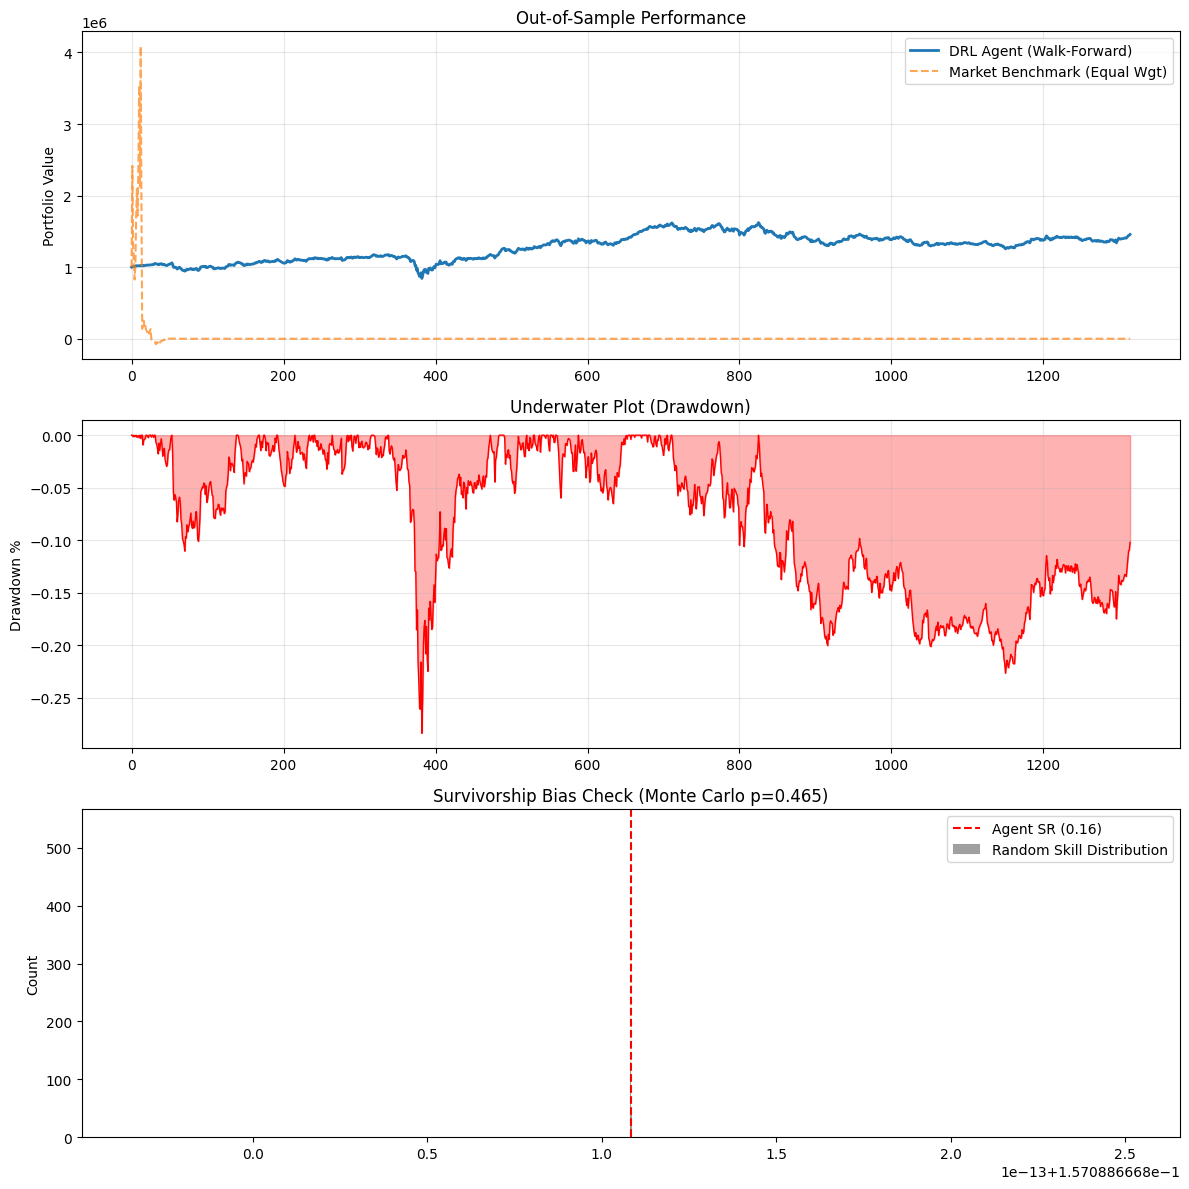


--- Generating Explainability Report ---


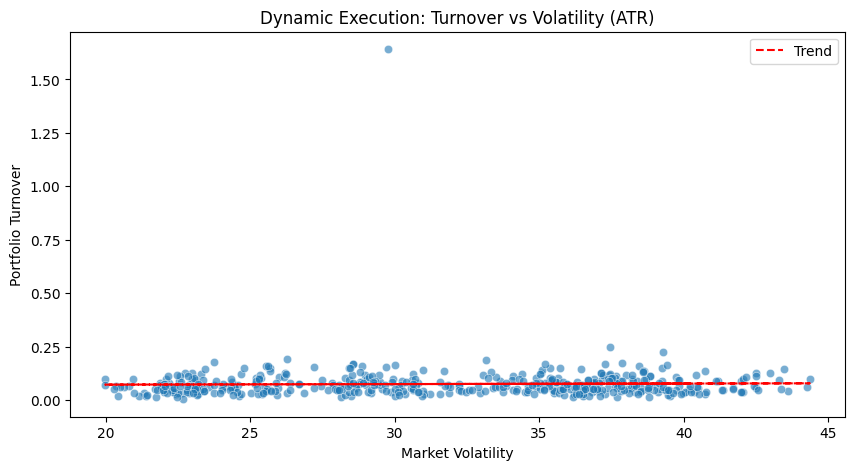

Calculating SHAP Values (this may take time)...


100%|██████████| 10/10 [00:04<00:00,  2.34it/s]


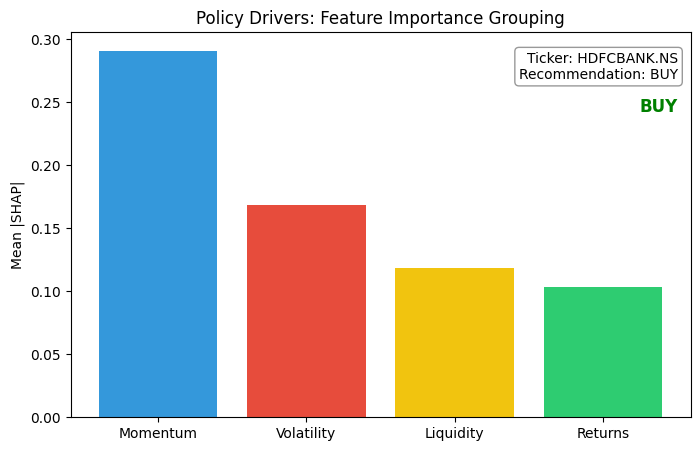

In [26]:
def run_experiment():
    # 1. Load Data
    TICKERS = ['RELIANCE.NS', 'INFY.NS', 'HDFCBANK.NS', 'TCS.NS']
    try:
        df_gym = fetch_and_process_data(TICKERS)
        print(f"Data Loaded: {df_gym.shape}")
    except Exception as e:
        print(f"Data Error: {e}"); return

    # 2. Bayesian Optimization (Optuna)
    print("\n--- Starting Bayesian Optimization ---")
    # Split for tuning (use first 60% for tuning to save time in demo)
    tune_size = int(len(df_gym) * 0.6)
    train_df = df_gym.iloc[:tune_size]
    test_df = df_gym.iloc[tune_size:]
    
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, train_df, test_df), n_trials=3)
    
    best_params = study.best_params
    print("\nBest Params:", best_params)

    # 3. Walk-Forward Validation
    print("\n--- Starting Walk-Forward Validation ---")
    wf_evaluator = WalkForwardEvaluator(df_gym, best_params)
    returns, equity_curve, benchmark_curve = wf_evaluator.run()

    if len(returns) < 10:
        print("Insufficient OOS data."); return

    # 4. Metrics & Statistical Significance
    print("\n--- Final Performance Metrics ---")
    sharpe = FinancialMetrics.get_sharpe_ratio(returns)
    sortino = FinancialMetrics.get_sortino_ratio(returns)
    max_dd = FinancialMetrics.get_max_drawdown(equity_curve)
    psr = FinancialMetrics.probabilistic_sharpe_ratio(returns)
    
    print(f"Total Return:       {((equity_curve[-1]/equity_curve[0])-1)*100:.2f}%")
    print(f"Sharpe Ratio:       {sharpe:.3f}")
    print(f"Sortino Ratio:      {sortino:.3f}")
    print(f"Max Drawdown:       {max_dd*100:.2f}%")
    print(f"Prob. Sharpe (PSR): {psr:.3f}")

    # Monte Carlo Permutation Test
    n_sims = 1000
    random_sharpes = []
    for _ in range(n_sims):
        shuffled = np.random.permutation(returns)
        random_sharpes.append(FinancialMetrics.get_sharpe_ratio(shuffled))
    
    random_sharpes = np.array(random_sharpes)
    p_value = np.sum(random_sharpes >= sharpe) / n_sims
    print(f"Monte Carlo P-Value: {p_value:.4f}")

    # 5. Visualizations
    plt.figure(figsize=(12, 12))
    
    # Plot A: Equity Curve vs Benchmark
    plt.subplot(3, 1, 1)
    # Align lengths if mismatched due to windowing
    min_len = min(len(equity_curve), len(benchmark_curve))
    plt.plot(equity_curve[:min_len], label='DRL Agent (Walk-Forward)', linewidth=2)
    plt.plot(benchmark_curve[:min_len], label='Market Benchmark (Equal Wgt)', linestyle='--', alpha=0.7)
    plt.title("Out-of-Sample Performance")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot B: Drawdown Analysis (Underwater Plot)
    plt.subplot(3, 1, 2)
    equity_series = pd.Series(equity_curve)
    rolling_max = equity_series.cummax()
    # Avoid division by zero
    drawdown = (equity_series - rolling_max) / (rolling_max + 1e-9)
    plt.fill_between(range(len(drawdown)), drawdown, 0, color='red', alpha=0.3)
    plt.plot(drawdown, color='red', linewidth=1)
    plt.title("Underwater Plot (Drawdown)")
    plt.ylabel("Drawdown %")
    plt.grid(True, alpha=0.3)

    # Plot C: Bootstrap Distribution (Fixed for Zero Variance)
    plt.subplot(3, 1, 3)

    # 1. Sanitize Data
    clean_random_sharpes = np.nan_to_num(random_sharpes)
    data_range = np.ptp(clean_random_sharpes)
    # 2. Adaptive Binning Logic
    if data_range < 1e-4:
        # If range is tiny, use fewer bins and disable KDE to prevent crash
        print(f"Warning: Random Sharpe range is near-zero ({data_range:.2e}). Using simplified histogram.")
        sns.histplot(clean_random_sharpes, kde=False, bins=5, label='Random Skill Distribution', color='gray')
    else:
        # Standard Plotting for healthy data
        sns.histplot(clean_random_sharpes, kde=True, bins=30, label='Random Skill Distribution', color='gray')
        
    plt.axvline(sharpe, color='red', linestyle='--', label=f'Agent SR ({sharpe:.2f})')
    plt.title(f"Survivorship Bias Check (Monte Carlo p={p_value:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 6. Run Explainability on Final Fold Data
    print("\n--- Generating Explainability Report ---")
    env_final = IndianEquityEnv(df_gym.iloc[-500:], reward_params=wf_evaluator.reward_params)
    model_final = PPO("MlpPolicy", env_final, policy_kwargs=wf_evaluator.policy_kwargs, verbose=0)
    model_final.learn(total_timesteps=1000)
    
    obs, _ = env_final.reset()
    obs_hist, turn_hist, atr_hist = [], [], []
    done = False
    while not done:
        obs_hist.append(obs)
        action, _ = model_final.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = env_final.step(action)
        turn_hist.append(info['turnover'])
        atr_hist.append(info['atr'])
        done = terminated or truncated
        
    analyze_agent(model_final, env_final, obs_hist, turn_hist, atr_hist)

if __name__ == "__main__":
    run_experiment()